In [ ]:
# Celda opcional: instalar dependencias en el entorno del kernel.
# Cambia INSTALL_DEPS a True solo si necesitas instalar/actualizar paquetes.
INSTALL_DEPS = False

if INSTALL_DEPS:
    import sys
    import subprocess

    packages = [
        "qnexus",
        "pytket",
        "pytket-offline-display",
        "numpy",
        "matplotlib",
    ]

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *packages])
    print("Dependencias instaladas/actualizadas.")
else:
    print("Instalación omitida (INSTALL_DEPS=False).")

# TFIM

Este notebook implementa una simulación digital del modelo **TFIM** (Transverse-Field Ising Model) con descomposición de Trotter de primer orden.

## Qué hace

- Define el Hamiltoniano del sistema.
- Construye circuitos trotterizados.
- Genera un barrido en razón \(h/J\) y tiempo \(t\).
- Compila y ejecuta los circuitos en QNexus.
- Recupera resultados para análisis posterior.

Para \(N\) espines:

$$
H = - J \sum_{i = 0}^{N-2} \sigma_{i}^{z} \sigma_{i+1}^{z} - h \sum_{i=0}^{N-1} \sigma_{i}^{x}
$$

Separamos como:

$$
H = H_{ZZ} + H_X,
$$

donde

$$
H_{ZZ} = - J \sum_{i = 0}^{N-2} \sigma_{i}^{z} \sigma_{i+1}^{z},
$$

y

$$
H_X = - h \sum_{i=0}^{N-1} \sigma_i^x.
$$

La evolución temporal se aproxima con Trotter:

$$
e^{-i(H_{ZZ}+H_X)t} \approx \left(e^{-iH_X\Delta t} e^{-iH_{ZZ}\Delta t}\right)^n,
$$

con

$$
\Delta t = \frac{t}{n}.
$$


## 1) Conexión y proyecto

Inicio de sesión en QNexus y configuración del proyecto activo.


In [38]:
import qnexus as qnx
qnx.login()
project = qnx.projects.get_or_create(
    name="Hackathon project",
)
qnx.context.set_active_project(project)

Already logged in. Tokens are valid.


## 2) Configuración del backend

Backend de simulación local (`AerState`) con 8 qubits.


In [39]:
n_qbits = 8
config = qnx.AerConfig(
    n_qubits=n_qbits,
)

## 3) Construcción del circuito trotterizado

Funciones para la evolución X, interacción ZZ y ensamblado de pasos de Trotter.


In [40]:
from pytket.circuit import Circuit
import numpy as np
import matplotlib.pyplot as plt
from pytket.extensions.offline_display import  render_circuit_jupyter

def build_trotter_step(
        c: Circuit,
        h: float,
        J: float,
        t: float,
        dt: float,
        n: int,
) -> None: 

    for q in range(n):
        add_x_evolution(c, q, h, dt)

    for q in range(n - 1):
        add_zz_evolution(c, q, q + 1, J, dt)

    c.add_barrier(range(n))

def add_x_evolution(
    c: Circuit,
    q: int,
    h: float,
    dt: float
) -> None:
    angle_x = (-2.0 * h * dt) / np.pi
    c.Rx(angle_x, q)

def add_zz_evolution(
    c: Circuit,
    q0: int,
    q1: int,
    J: float,
    dt: float
) -> None:
    angle_zz = (- 2.0 * J * dt) / np.pi
    c.CX(q0, q1)
    c.Rz(angle_zz, q1)
    c.CX(q0, q1)

def build_trotter_circuit(
        h: float,
        J: float,
        t: float,
        steps: int,
        n_qbits: int
) -> Circuit:
    dt = t / steps
    c = Circuit(n_qbits, n_qbits)
    n_steps = int(t / dt)
    for _ in range(n_steps):
        build_trotter_step(c, h, J, t, dt, n_qbits)
    
    return c

## 4) Ejemplo mínimo

Circuito de 2 qubits para inspeccionar visualmente la estructura trotterizada.


In [41]:
circuit = build_trotter_circuit(
    h=1.0,
    J=1.0,
    t=1.0,
    steps=10,
    n_qbits=2
    )

render_circuit_jupyter(circuit)

## 5) Generación del barrido TFIM

Función que genera los circuitos para cada combinación de \(h/J\) y tiempo, con metadatos de trazabilidad.


In [42]:
import datetime

def generate_tfim_trotter_scan(
    hj_ratios,
    times,
    J=1.0,
    steps=100,
    n=8,
    measure=True,
    name_prefix="tfim",
):
    """
    Genera todos los circuitos del barrido TFIM.

    El orden de salida es ratio -> tiempo. Ese orden es el que usan
    las celdas de simulacion local y las graficas posteriores.
    """
    jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H_%M_%S")
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)

    circuits = []
    scan_records = []

    for ratio_index, ratio in enumerate(ratios):
        for time_index, t in enumerate(times):
            circuit_index = len(circuits)
            circuit_name = f"{name_prefix}-{jobname_suffix}-{circuit_index}"

            circuit = build_trotter_circuit(
                h=ratio * J,
                J=J,
                t=t,
                steps=steps,
                n_qbits=n,
            )
            if measure:
                circuit.measure_all()

            circuits.append(circuit)
            scan_records.append(
                {
                    "index": circuit_index,
                    "ratio_index": ratio_index,
                    "time_index": time_index,
                    "ratio": float(ratio),
                    "time": float(t),
                    "J": float(J),
                    "steps": int(steps),
                    "dt": float(t / steps),
                    "n": int(n),
                    "name": circuit_name,
                }
            )

    return circuits, scan_records, jobname_suffix

## 6) Parámetros y subida de circuitos

Barrido sobre \(h/J\) y tiempos; los circuitos generados se suben a QNexus.


In [43]:
hj_ratios = np.array([0.5, 0.9, 1.0, 1.1, 2.0])
times_simulator = np.linspace(0, 1, 25)
times_simulator = times_simulator[times_simulator > 0.0]
J = 1.0
steps = 25
n = 8

circuits, scan_records, jobname_suffix = generate_tfim_trotter_scan(
    hj_ratios=hj_ratios,
    times=times_simulator,
    J=J,
    steps=steps,
    n=n,
    measure=True,
)


jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H-%M-%S")
refs = []
for circuit in circuits:
    refs.append(qnx.circuits.upload(circuit=circuit, name=f"GHZ-Circuit-{jobname_suffix}"))

## 7) Compilación

Compilación de los circuitos subidos con optimización nivel 2.


In [44]:
ref_compile_job = qnx.start_compile_job(
    programs=refs,
    backend_config=config,
    optimisation_level=2,
    name=f"compilation-job-{jobname_suffix}",
)
qnx.jobs.wait_for(ref_compile_job)


JobStatus(status=<JobStatusEnum.COMPLETED: 'COMPLETED'>, message='The job is completed.', error_detail=None, completed_time=datetime.datetime(2026, 7, 23, 3, 17, 12, 808291, tzinfo=datetime.timezone.utc), queued_time=datetime.datetime(2026, 7, 23, 3, 14, 52, 648096, tzinfo=datetime.timezone.utc), submitted_time=datetime.datetime(2026, 7, 23, 3, 14, 47, 408892, tzinfo=datetime.timezone.utc), running_time=datetime.datetime(2026, 7, 23, 3, 14, 52, 968145, tzinfo=datetime.timezone.utc), cancelled_time=None, error_time=None, queue_position=None, cost=None)

## 8) Ejecución

Lanzamiento del job con 10 000 shots por circuito.


In [ ]:
compiled_circuits = [item.get_output() for item in qnx.jobs.results(ref_compile_job)]

my_execute_job_ref = qnx.start_execute_job(
    programs=compiled_circuits,
    backend_config=config,
    n_shots=[10_000] * len(refs),
    name=f"execute-job-{jobname_suffix}",
    project=project,
)

## 9) Guardado del job

Persistencia local de la referencia para recuperar resultados sin depender de variables en memoria.


In [ ]:
from pathlib import Path
qnx.filesystem.save(
    ref=my_execute_job_ref,
    path=Path.cwd() / "my_job_folder" / f"execute-job-{jobname_suffix}",
    mkdir=True,
)

## 10) Resultados

Descarga y estructuración de los resultados en `execution_records` para análisis posterior.


In [ ]:
execute_results_refs = qnx.jobs.results(qnx.filesystem.load(path=Path.cwd() / "my_job_folder" / f"execute-job-{jobname_suffix}"))
execute_results = [execute_results_refs[i].download_result() for i in range(len(execute_results_refs))]

AttributeError: 'BackendResult' object has no attribute 'record'

In [ ]:
execution_records = []
for scan_record, result in zip(scan_records, execute_results):
    execution_record = scan_record.copy()
    execution_record["backend_result"] = result
    execution_records.append(execution_record)

/var/folders/_8/c7dhktt53gb50q4gryyhbks00000gn/T/ipykernel_6392/517303780.py:12: DeprecationWarning: The `BackendResult.get_distribution()` method is deprecated: please use `get_empirical_distribution()` or `get_probability_distribution()` instead.
  dist = result.get_distribution()


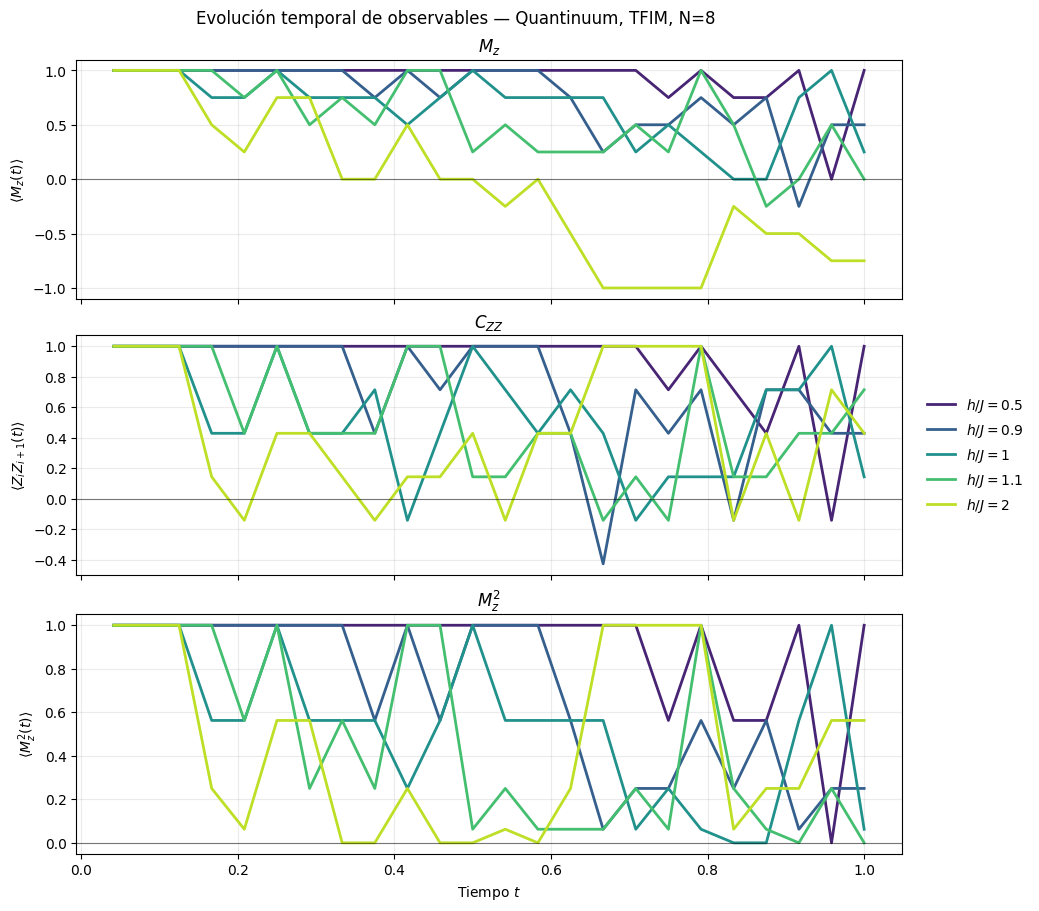

In [ ]:
import numpy as np


def z_observables_from_probabilities(
    result,
    n: int,
) -> tuple[float, float, float]:
    """
    Calcula <Mz>, <Mz²> y <Czz> desde un BackendResult de AerState.
    Usa get_distribution() para obtener probabilidades exactas del vector de estado.
    """
    dist = result.get_distribution()

    mz = 0.0
    mz2 = 0.0
    czz = 0.0

    for bitstring, probability in dist.items():
        if isinstance(bitstring, str):
            bits = np.array(
                [int(bit) for bit in bitstring],
                dtype=int,
            )
        else:
            bits = np.array(
                tuple(bitstring),
                dtype=int,
            )

        if bits.shape != (n,):
            raise ValueError(
                f"Cada bitstring debe tener longitud {n}, "
                f"pero se recibió {tuple(bits)}."
            )

        # Medición |0> -> autovalor +1 de Z
        # Medición |1> -> autovalor -1 de Z
        z_values = 1 - 2 * bits

        mz_sample = np.mean(z_values)
        czz_sample = np.mean(z_values[:-1] * z_values[1:])

        mz += probability * mz_sample
        mz2 += probability * mz_sample**2
        czz += probability * czz_sample

    return float(mz), float(mz2), float(czz)


def observables_from_execution_records(execution_records, hj_ratios=None, times=None, n=8):
    ratios = np.sort(np.asarray(hj_ratios, dtype=float))
    times = np.asarray(times, dtype=float)

    mz_data = np.full((len(ratios), len(times)), np.nan)
    mz2_data = np.full_like(mz_data, np.nan)
    czz_data = np.full_like(mz_data, np.nan)

    for record in execution_records:
        ratio_index = np.where(np.isclose(ratios, record["ratio"]))[0]
        time_index = np.where(np.isclose(times, record["time"]))[0]

        mz, mz2, czz = z_observables_from_probabilities(record["backend_result"], n)
        mz_data[ratio_index[0], time_index[0]] = mz
        mz2_data[ratio_index[0], time_index[0]] = mz2
        czz_data[ratio_index[0], time_index[0]] = czz

    return ratios, times, mz_data, mz2_data, czz_data


def graph_quantinuum_observables_in_time(execution_records, hj_ratios=None, times=None, n=8):
    ratios, times, mz_data, mz2_data, czz_data = observables_from_execution_records(
        execution_records, hj_ratios, times, n
    )

    targets = [0.5, 0.9, 1.0, 1.1, 2.0]
    selected = sorted(set(np.abs(ratios - x).argmin() for x in targets))
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected)))

    fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, constrained_layout=True)
    plots = [
        (axes[0], mz_data, r"$\langle M_z(t) \rangle$", r"$M_z$"),
        (axes[1], czz_data, r"$\langle Z_i Z_{i+1}(t) \rangle$", r"$C_{ZZ}$"),
        (axes[2], mz2_data, r"$\langle M_z^2(t) \rangle$", r"$M_z^2$"),
    ]

    for ax, data, symbol, name in plots:
        for color, index in zip(colors, selected):
            ax.plot(
                times, data[index], color=color, linewidth=2,
                label=fr"$h/J={ratios[index]:.3g}$",
            )
        ax.set_ylabel(symbol)
        ax.set_title(name)
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel(r"Tiempo $t$")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.suptitle(f"Evolución temporal de observables — Quantinuum, TFIM, N={n}")
    plt.show()


graph_quantinuum_observables_in_time(
    execution_records=execution_records,
    hj_ratios=hj_ratios,
    times=times_simulator,
    n=n,
)